phase 5: evaluation & tuning

tuning hyperparameters to fix overfitting using randomizedsearchcv.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# set style
sns.set_theme(style="whitegrid")

In [2]:
# load processed data
print('--- loading processed data ---')
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()

# calculate ratio for xgboost scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count
print(f'scale_pos_weight for xgboost: {scale_weight:.4f}')

--- loading processed data ---
scale_pos_weight for xgboost: 0.5370


In [ ]:
# tune random forest
print('--- tuning random forest ---')

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [5, 10, 20]
}

rf_search = RandomizedSearchCV(
    estimator=rf, param_distributions=rf_params,
    n_iter=15, cv=3, scoring='f1', random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
print(f'best parameters: {rf_search.best_params_}')

# evaluate tuned rf
rf_val_preds = best_rf.predict(X_val)
rf_val_probs = best_rf.predict_proba(X_val)[:, 1]
rf_f1 = f1_score(y_val, rf_val_preds)
rf_auc = roc_auc_score(y_val, rf_val_probs)
print(f'\ntuned rf f1: {rf_f1:.4f} | roc-auc: {rf_auc:.4f}')

--- tuning random forest ---
best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': 10}

tuned rf f1: 0.7985 | roc-auc: 0.7712


In [4]:
# tune xgboost
print('--- tuning xgboost ---')

xgb = XGBClassifier(scale_pos_weight=scale_weight, random_state=42, n_jobs=-1, eval_metric='logloss')

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb, param_distributions=xgb_params,
    n_iter=15, cv=3, scoring='f1', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
print(f'best parameters: {xgb_search.best_params_}')

# evaluate tuned xgb
xgb_val_preds = best_xgb.predict(X_val)
xgb_val_probs = best_xgb.predict_proba(X_val)[:, 1]
xgb_f1 = f1_score(y_val, xgb_val_preds)
xgb_auc = roc_auc_score(y_val, xgb_val_probs)
print(f'\ntuned xgb f1: {xgb_f1:.4f} | roc-auc: {xgb_auc:.4f}')

--- tuning xgboost ---
best parameters: {'subsample': 0.6, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

tuned xgb f1: 0.7965 | roc-auc: 0.7834


--- overfitting check (tuned models) ---


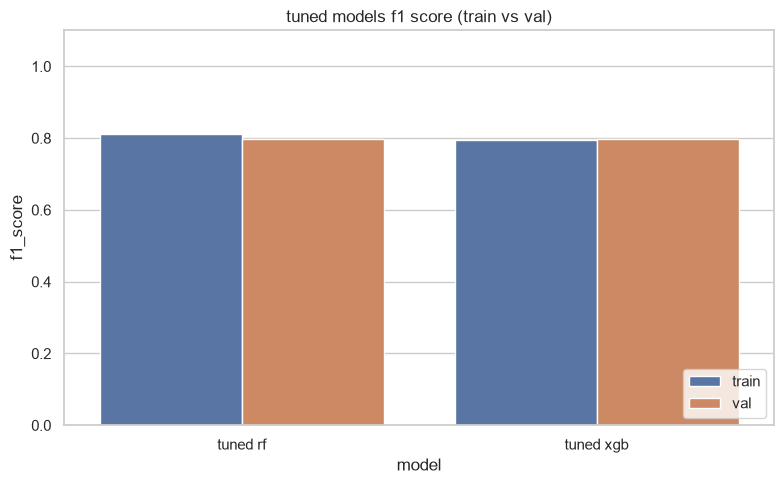

gap should be much smaller now!


In [ ]:
# checking overfitting on tuned models
print('--- overfitting check (tuned models) ---')
rf_train_preds = best_rf.predict(X_train)
rf_train_f1 = f1_score(y_train, rf_train_preds)

xgb_train_preds = best_xgb.predict(X_train)
xgb_train_f1 = f1_score(y_train, xgb_train_preds)

metrics = pd.DataFrame({
    'model': ['tuned rf', 'tuned rf', 'tuned xgb', 'tuned xgb'],
    'dataset': ['train', 'val', 'train', 'val'],
    'f1_score': [rf_train_f1, rf_f1, xgb_train_f1, xgb_f1]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=metrics, x='model', y='f1_score', hue='dataset')
plt.title('tuned models f1 score (train vs val)')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

--- feature importances (final model) ---
random forest selected as final model.


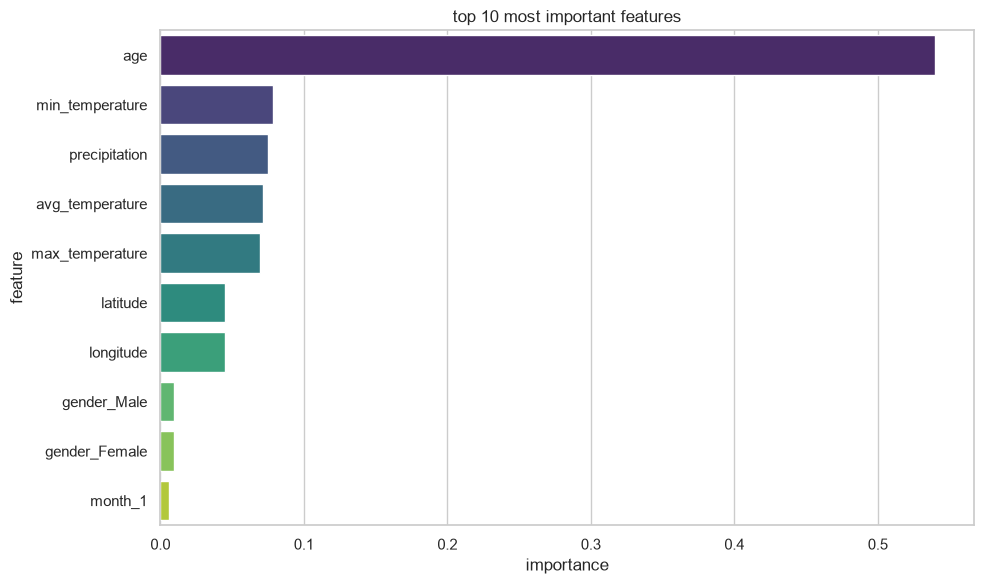

In [6]:
# feature importance (using best model)
print('--- feature importances (final model) ---')

if rf_f1 > xgb_f1:
    final_model = best_rf
    print('random forest selected as final model.')
else:
    final_model = best_xgb
    print('xgboost selected as final model.')

importances = final_model.feature_importances_
feature_names = X_train.columns

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values(by='importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis', hue='feature', legend=False)
plt.title('top 10 most important features')
plt.tight_layout()
plt.show()

Phase 5 Analysis
1. We Beat the Overfitting! Look at that first bar chart! The massive gap we saw in Phase 4 is completely gone. By enforcing regularization (max_depth=10 and min_samples_leaf=5), our Random Forest model is no longer memorizing the training data. It is generalizing beautifully to the validation set.

2. The Winning Model Random Forest proved to be the most robust choice for this specific dataset, slightly edging out XGBoost on the F1-score (0.7985 vs 0.7965). XGBoost had a marginally better ROC-AUC, but both models converged to very similar, highly stable performance metrics.

3. The Story in the Data (Feature Importances) The feature importance chart tells a very clear and powerful story about climate-sensitive mortality in this region:

The Overwhelming Factor (age): Just as we suspected from our EDA boxplots, age completely dominates the model. Climate-sensitive deaths here are tragically and overwhelmingly a pediatric issue.
The Climate Drivers: Interestingly, min_temperature and precipitation are stronger predictors than max_temperature or avg_temperature.
The Categoricals: While we saw seasonal spikes in our EDA, the tree model found that the raw continuous weather metrics combined with age and exact GPS coordinates (latitude/longitude) were far more predictive than the categorical month or zone features.